In [ ]:
!pip install -U tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 801.7 kB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.20.0 which is incompatible.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but you have tensorflow 2.20.0 which is incompatible.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.20.0 which is incompatible.


In [ ]:
import tensorflow as tf

print(tf.__version__)

2.20.0


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
dataset = pd.read_csv('/content/Churn_Modelling.csv')

In [ ]:
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
dataset.shape

(10000, 14)

In [ ]:
X = dataset.iloc[:, 3:13] ### All independent features

y = dataset.iloc[:, 13] ## All Dependent Features

In [ ]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [ ]:
y

,Exited
0,1
1,0
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,1
9998,1


In [ ]:
X.shape

(10000, 10)

In [ ]:
# Feature Engineering

geography = pd.get_dummies(X['Geography'], drop_first=True)

gender = pd.get_dummies(X['Gender'], drop_first=True)

In [ ]:
X = X.drop(['Geography', 'Gender'], axis=1)

In [ ]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,42,2,0.00,1,1,1,101348.88
1,608,41,1,83807.86,1,0,1,112542.58
2,502,42,8,159660.80,3,1,0,113931.57
3,699,39,1,0.00,2,0,0,93826.63
4,850,43,2,125510.82,1,1,1,79084.10


Concatination

In [ ]:
X = pd.concat([X, geography, gender], axis=1)

In [ ]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

In [ ]:
## Feature Scaling

from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train = sc.fit_transform(X_train)

X_test = sc.transform(X_test)

In [ ]:
X_train

array([[ 0.16958176, -0.46460796,  0.00666099, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-2.30455945,  0.30102557, -1.37744033, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-1.19119591, -0.94312892, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       ...,
       [ 0.9015152 , -0.36890377,  0.00666099, ..., -0.5698444 ,
        -0.57369368,  0.91601335],
       [-0.62420521, -0.08179119,  1.39076231, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-0.28401079,  0.87525072, -1.37744033, ...,  1.75486502,
        -0.57369368, -1.09168714]])

In [ ]:
X_test

array([[-0.55204276, -0.36890377,  1.04473698, ...,  1.75486502,
        -0.57369368, -1.09168714],
       [-1.31490297,  0.10961719, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       [ 0.57162971,  0.30102557,  1.04473698, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       ...,
       [-0.74791227, -0.27319958, -1.37744033, ..., -0.5698444 ,
         1.74309049,  0.91601335],
       [-0.00566991, -0.46460796, -0.33936434, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-0.79945688, -0.84742473,  1.04473698, ...,  1.75486502,
        -0.57369368,  0.91601335]])

In [ ]:
X_train.shape

(8000, 11)

In [ ]:
### Lets create ANN
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU, PReLU, ELU, ReLU
from tensorflow.keras.layers import Dropout

In [ ]:
## Let's initialize the ANN
classifier = Sequential()

In [ ]:
## adding the input layer
classifier.add(Dense(units=11, activation='relu'))

In [ ]:
## adding the first hidden layer
classifier.add(Dense(units=7, activation='relu'))

## adding dropout layer
# classifier.add(Dropout(0.3))

In [ ]:
## adding the 2nd hidden layer
classifier.add(Dense(units=6, activation='relu'))
## adding dropout layer
# classifier.add(Dropout(0.3))


In [ ]:
### adding the output layer
classifier.add(Dense(units=1, activation='sigmoid'))

In [ ]:
classifier.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
opt = tf.keras.optimizers.Adam(learning_rate=0.01)

In [ ]:
model_history = classifier.fit(X_train, y_train, validation_split=0.33, batch_size=10, epochs=100)

Epoch 1/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7360 - loss: 0.5795 - val_accuracy: 0.7955 - val_loss: 0.4562
Epoch 2/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8076 - loss: 0.4294 - val_accuracy: 0.7955 - val_loss: 0.4421
Epoch 3/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8033 - loss: 0.4236 - val_accuracy: 0.7955 - val_loss: 0.4383
Epoch 4/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7919 - loss: 0.4326 - val_accuracy: 0.8107 - val_loss: 0.4331
Epoch 5/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8068 - loss: 0.4372 - val_accuracy: 0.8239 - val_loss: 0.4163
Epoch 6/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8450 - loss: 0.3815 - val_accuracy: 0.8307 - val_loss: 0.3963
Epoch 7/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8410 - loss: 0.3801 - val_accuracy: 0.8395 - val_loss: 0.3832
Epoch 8/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8554 - loss: 0.3515 - val_accu

In [ ]:
model_history.history

{'accuracy': [0.7775704264640808,
  0.7962306141853333,
  0.7962306141853333,
  0.8063071370124817,
  0.8236611485481262,
  0.8397089242935181,
  0.8503451943397522,
  0.854637086391449,
  0.8574360609054565,
  0.8583691120147705,
  0.8596752882003784,
  0.8598619103431702,
  0.8593021035194397,
  0.857995867729187,
  0.8615413308143616,
  0.858928918838501,
  0.8622877597808838,
  0.863220751285553,
  0.8628475666046143,
  0.8639671802520752,
  0.8643403649330139,
  0.8645269870758057,
  0.8634073734283447,
  0.8654599785804749,
  0.8658331632614136,
  0.8660197854042053,
  0.8662064075469971,
  0.8658331632614136,
  0.8649001717567444,
  0.8634073734283447,
  0.8660197854042053,
  0.8649001717567444,
  0.8669527769088745,
  0.8682590126991272,
  0.8665795922279358,
  0.8680723905563354,
  0.8658331632614136,
  0.8665795922279358,
  0.8667662143707275,
  0.8671393990516663,
  0.867326021194458,
  0.8690053820610046,
  0.8669527769088745,
  0.8676992058753967,
  0.8678858280181885,
  0

In [ ]:
model_history.history.keys

<function dict.keys>

In [ ]:
### Early stopping
import tensorflow as tf
from tensorflow import keras
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0,
)

In [ ]:
model_history = classifier.fit(X_train, y_train, validation_split=0.33, batch_size=10, epochs=100, callbacks=[early_stopping])

Epoch 1/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8764 - loss: 0.2925 - val_accuracy: 0.8489 - val_loss: 0.3700
Epoch 2/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8667 - loss: 0.2996 - val_accuracy: 0.8508 - val_loss: 0.3722
Epoch 3/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8776 - loss: 0.3006 - val_accuracy: 0.8535 - val_loss: 0.3717
Epoch 4/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8729 - loss: 0.2987 - val_accuracy: 0.8527 - val_loss: 0.3680
Epoch 5/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8695 - loss: 0.3092 - val_accuracy: 0.8516 - val_loss: 0.3672
Epoch 6/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8724 - loss: 0.3078 - val_accuracy: 0.8497 - val_loss: 0.3726
Epoch 7/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8689 - loss: 0.3023 - val_accuracy: 0.8546 - val_loss: 0.3695
Epoch 8/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8777 - loss: 0.3022 - val_accu

In [ ]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

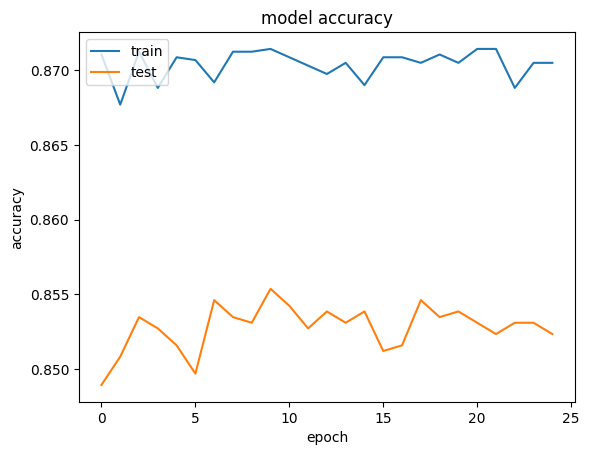

In [ ]:
## summarize history for accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

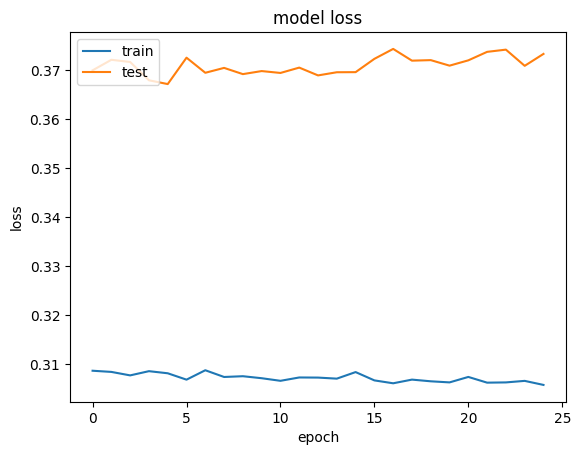

In [ ]:
## summarize history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [ ]:
## making the predictions and evaluating the model

## predicting the test set results

y_pred = classifier.predict(X_test)
y_pred = (y_pred > 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
## make the confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

In [ ]:
## calculate the accuracy
from sklearn.metrics import accuracy_score

score = accuracy_score(y_pred, y_test)

In [ ]:
score

0.859

In [ ]:
## get the weights
classifier.get_weights()

[array([[ 0.61103046, -0.02632546, -0.14031984,  0.23790948, -0.4891931 ,
         -0.08339715,  0.09604108, -0.1802076 , -0.25329316, -0.3546013 ,
         -0.23936413],
        [-0.39211378,  0.75465286, -0.4761703 , -0.5005271 , -0.18465936,
          0.55137485, -0.5593403 , -0.30358514,  1.0943242 , -0.8707841 ,
         -0.32571393],
        [ 0.03518024,  0.02978683, -0.63700897, -0.31098324, -0.11548536,
         -0.11298173,  0.18842073,  0.0614564 , -0.11252902,  0.09811372,
          0.31780457],
        [-0.33731192,  0.19794393,  0.62972766, -1.0332384 ,  0.5114835 ,
         -0.28149718,  0.36363438, -0.28110012, -0.29089653,  0.74335515,
         -0.62398034],
        [ 1.1906273 , -0.3908512 , -0.43442178,  0.00420863,  1.3714802 ,
          0.48063758, -0.19866319, -0.2397233 , -0.9953586 ,  0.23685433,
         -0.08412254],
        [ 0.05595771,  0.00154236, -0.21533015,  0.57251143, -0.04532998,
         -0.25263378,  0.8525117 , -0.16820711, -0.21896827,  0.3811384